# Periodic ERC Model — Final Clean Notebook

This notebook reproduces the ERC dynamic accessibility scan across 118 elements.

It expects the repository structure:

```text
Periodic_ERC_Model/
├── data/
│   ├── input/
│   │   ├── global_transition_pathway_summary_final_element_scaled.csv
│   │   └── full_periodic_oxygen_likeness_scan.csv
│   └── output/
├── figures/
├── notebooks/
└── paper/
```

The notebook does **not** require the author's Google Drive.  
If running from Google Colab using a Drive folder, mount Drive and set `PROJECT_ROOT_OVERRIDE`.

In [1]:
# OPTIONAL — only needed if you are running this notebook from Google Drive in Colab.
# Leave commented for GitHub/local use.

# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Locate project root

In [3]:
# --------------------------------------------------
# Robust project root detection for Colab + GitHub
# --------------------------------------------------

from pathlib import Path
import os

# Optional: mount Google Drive only if running in Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

PROJECT_FOLDER_NAME = "Periodic_ERC_Model"

def find_project_root():
    candidates = []

    # 1. Current working directory and parents
    cwd = Path.cwd().resolve()
    candidates += [cwd, cwd.parent, cwd.parent.parent]

    # 2. Common Colab / Drive locations
    candidates += [
        Path("/content") / PROJECT_FOLDER_NAME,
        Path("/content/drive/MyDrive") / PROJECT_FOLDER_NAME,
        Path("/content/drive/MyDrive/Colab Notebooks") / PROJECT_FOLDER_NAME,
    ]

    # 3. Search inside /content and Drive
    search_roots = [
        Path("/content"),
        Path("/content/drive/MyDrive"),
    ]

    for root in search_roots:
        if root.exists():
            matches = list(root.glob(f"**/{PROJECT_FOLDER_NAME}"))
            candidates += matches

    # Find candidate with data/input
    for candidate in candidates:
        if candidate.exists() and (candidate / "data").exists():
            data_dir = candidate / "data"

            input_dirs = [
                p for p in data_dir.iterdir()
                if p.is_dir() and p.name.lower() == "input"
            ]

            if input_dirs:
                return candidate.resolve()

    raise FileNotFoundError(
        "Could not find Periodic_ERC_Model with data/input inside it."
    )

def find_subdir(parent, name):
    for p in parent.iterdir():
        if p.is_dir() and p.name.lower() == name.lower():
            return p
    raise FileNotFoundError(f"Missing folder '{name}' inside {parent}")

BASE_DIR = find_project_root()

DATA_DIR = find_subdir(BASE_DIR, "data")
INPUT_DIR = find_subdir(DATA_DIR, "input")
OUTPUT_DIR = find_subdir(DATA_DIR, "output")
FIGURE_DIR = find_subdir(BASE_DIR, "figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("INPUT_DIR:", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

print("\nInput files found:")
for p in sorted(INPUT_DIR.glob("*.csv")):
    print("-", p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR: /content/drive/MyDrive/Colab Notebooks/Periodic_ERC_Model
INPUT_DIR: /content/drive/MyDrive/Colab Notebooks/Periodic_ERC_Model/data/input
OUTPUT_DIR: /content/drive/MyDrive/Colab Notebooks/Periodic_ERC_Model/data/output
FIGURE_DIR: /content/drive/MyDrive/Colab Notebooks/Periodic_ERC_Model/figures

Input files found:
- full_periodic_oxygen_likeness_scan.csv
- global_transition_pathway_summary_final_element_scaled.csv


## 2. Load required input data

In [4]:
RADIUS_FILE = INPUT_DIR / "global_transition_pathway_summary_final_element_scaled.csv"
GEOMETRY_FILE = INPUT_DIR / "full_periodic_oxygen_likeness_scan.csv"

for required_file in [RADIUS_FILE, GEOMETRY_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Missing required input file: {required_file}\n"
            "Place the required CSV files in data/input/ and re-run this cell."
        )

base_118_df = pd.read_csv(RADIUS_FILE)
geometry_118_df = pd.read_csv(GEOMETRY_FILE)

print("Radius table:", base_118_df.shape)
print("Geometry table:", geometry_118_df.shape)
print("Unique elements in radius table:", base_118_df["element"].nunique())
print("Unique elements in geometry table:", geometry_118_df["element"].nunique())

display(base_118_df.head())
display(geometry_118_df.head())

Radius table: (118, 14)
Geometry table: (118, 29)
Unique elements in radius table: 118
Unique elements in geometry table: 118


,element,r_core,r_boundary,first_weak,first_damage,first_nonreturn,pathway_class,refined_weak,refined_damage,refined_nonreturn,final_weak,final_damage,final_nonreturn,final_pathway_class
0,O,1.828194,3.466324,NaN,0.886207,0.755172,damage/nonreturn coupled,NaN,0.800000,0.731034,NaN,0.800000,0.731034,damage/nonreturn coupled
1,S,1.455016,2.159713,NaN,0.624138,0.624138,damage/nonreturn coupled,NaN,0.565517,0.600000,NaN,0.565517,0.600000,damage/nonreturn coupled
2,I,1.441289,2.274677,NaN,0.624138,0.624138,damage/nonreturn coupled,NaN,0.572414,0.593103,NaN,0.572414,0.593103,damage/nonreturn coupled
3,Cl,1.889966,3.568111,NaN,0.886207,0.755172,damage/nonreturn coupled,NaN,0.806897,0.751724,NaN,0.806897,0.751724,damage/nonreturn coupled
4,Br,1.626778,2.785923,NaN,0.689655,0.689655,damage/nonreturn coupled,NaN,0.651724,0.658621,NaN,0.651724,0.658621,damage/nonreturn coupled


,element,name,regime_label,oxygen_relation_class_3d,distance_to_oxygen_3d,oxygen_similarity_score_3d,oxygen_compatibility_index,oxygen_affinity_proxy,redox_flexibility_proxy,electronegativity,...,distance_to_oxygen_2d,distance_to_sulfur_3d,sulfur_similarity_score_3d,distance_to_sulfur_2d,mean_oxygen_likeness,geometric_stability,global_class,curvature,geometric_stability_v2,cluster
0,O,Oxygen,buffer / catalytic regime,oxygen-core,0.000000,1.000000,0.964706,1.00,0.80,3.44,...,0.000000,1.455016,0.844856,1.432734,1.000000,1.000000,core oxygen-like,NaN,0.974184,2
1,S,Sulfur,buffer / catalytic regime,oxygen-near,1.455016,0.857701,0.845139,0.85,0.75,2.58,...,1.432734,0.000000,1.000000,0.000000,0.857701,0.407329,transitional,NaN,0.974184,2
2,I,Iodine,strong binding / low flexibility regime,oxygen-near,1.477016,0.855550,0.718808,0.82,0.42,2.66,...,1.434086,0.798911,0.914814,0.519223,0.855550,0.403712,transitional,1.433015,0.411013,3
3,Cl,Chlorine,strong binding / low flexibility regime,oxygen-near,1.577976,0.845676,0.695800,0.78,0.40,3.16,...,1.476413,1.889966,0.798478,1.865470,0.845676,0.387901,transitional,0.078959,0.926819,2
4,Br,Bromine,structural / support regime,oxygen-near,1.626778,0.840903,0.674832,0.74,0.38,2.96,...,1.624957,1.391668,0.851610,1.380404,0.840903,0.380694,transitional,0.052158,0.950428,2


In [5]:
required_radius_cols = {"element", "r_core", "r_boundary"}
missing_radius_cols = required_radius_cols - set(base_118_df.columns)
if missing_radius_cols:
    raise ValueError(f"Missing required columns in radius table: {missing_radius_cols}")

distance_candidates = [
    col for col in geometry_118_df.columns
    if "distance" in col.lower() and ("oxygen" in col.lower() or "_o" in col.lower())
]

if "distance_to_oxygen_3d" in geometry_118_df.columns:
    distance_col = "distance_to_oxygen_3d"
elif "distance_to_o" in geometry_118_df.columns:
    distance_col = "distance_to_o"
elif "distance_to_O" in geometry_118_df.columns:
    distance_col = "distance_to_O"
elif len(distance_candidates) > 0:
    distance_col = distance_candidates[0]
else:
    raise ValueError("No oxygen-distance column found in geometry table.")

print("Using distance column:", distance_col)

Using distance column: distance_to_oxygen_3d


## 3. Build element parameter dictionary

In [6]:
full_element_radii = (
    base_118_df[["element", "r_core", "r_boundary"]]
    .dropna()
    .drop_duplicates("element")
)

element_radii = {
    row["element"]: {
        "r_core": float(row["r_core"]),
        "r_boundary": float(row["r_boundary"])
    }
    for _, row in full_element_radii.iterrows()
}

elements_to_run = list(element_radii.keys())

print("Elements loaded:", len(elements_to_run))
print(elements_to_run[:20])

Elements loaded: 118
['O', 'S', 'I', 'Cl', 'Br', 'Se', 'Te', 'At', 'C', 'Au', 'F', 'Pt', 'Po', 'P', 'As', 'Ir', 'Si', 'Cu', 'Rh', 'Ni']


## 4. ERC model functions

In [7]:
dt = 0.01
t = np.arange(0, 10, dt)

a = 1.0
b = 0.5
c = 0.8

def gaussian_pulse(t, A, sigma, t0=3.0):
    return A * np.exp(-0.5 * ((t - t0) / sigma)**2)

def get_radii(element):
    return (
        element_radii[element]["r_core"],
        element_radii[element]["r_boundary"]
    )

In [8]:
def simulate_trajectory(
    element,
    A,
    sigma,
    k_memory=0.0,
    damage_threshold=0.1,
    t=t,
    dt=dt
):
    r_core, r_boundary = get_radii(element)

    x = np.zeros_like(t)
    y = np.zeros_like(t)
    r = np.zeros_like(t)
    damage = np.zeros_like(t)

    pulse = gaussian_pulse(t, A, sigma)

    first_damage = None
    first_nonreturn = None

    for i in range(1, len(t)):
        ri = np.sqrt(x[i-1]**2 + y[i-1]**2)

        scale = ri / r_core if r_core > 0 else ri
        recovery_strength = a / (1.0 + b * scale**c)

        forcing = pulse[i]

        dx = (-recovery_strength * x[i-1] + forcing) * dt
        dy = (-recovery_strength * y[i-1] + 0.5 * forcing) * dt

        x[i] = x[i-1] + dx
        y[i] = y[i-1] + dy

        r[i] = np.sqrt(x[i]**2 + y[i]**2)

        excess = max(0.0, r[i] - r_core)
        damage[i] = damage[i-1] + excess * dt + k_memory * damage[i-1] * dt

        if first_damage is None and damage[i] >= damage_threshold:
            first_damage = t[i]

        if first_nonreturn is None and r[i] >= r_boundary:
            first_nonreturn = t[i]

    return {
        "element": element,
        "A": A,
        "sigma": sigma,
        "r_core": r_core,
        "r_boundary": r_boundary,
        "first_damage": first_damage,
        "first_nonreturn": first_nonreturn,
        "max_r": np.max(r),
        "final_damage": damage[-1],
    }

In [9]:
def run_element_pipeline(
    element,
    A_values,
    sigma_values,
    k_memory=0.0,
    damage_threshold=0.1
):
    rows = []

    for A in A_values:
        for sigma in sigma_values:
            sim = simulate_trajectory(
                element=element,
                A=A,
                sigma=sigma,
                k_memory=k_memory,
                damage_threshold=damage_threshold
            )

            fd = sim["first_damage"]
            fn = sim["first_nonreturn"]

            if fd is not None and fn is not None:
                delta = fd - fn
                if delta < 0:
                    regime = "damage-before-nonreturn"
                elif delta == 0:
                    regime = "coupled"
                else:
                    regime = "nonreturn-before-damage"
            elif fd is not None and fn is None:
                delta = np.nan
                regime = "damage-only"
            elif fd is None and fn is not None:
                delta = np.nan
                regime = "nonreturn-only"
            else:
                delta = np.nan
                regime = "no-transition"

            rows.append({
                "element": element,
                "A": A,
                "sigma": sigma,
                "k_memory": k_memory,
                "damage_threshold": damage_threshold,
                "first_damage": fd,
                "first_nonreturn": fn,
                "delta_damage_minus_nonreturn": delta,
                "regime": regime,
                "max_r": sim["max_r"],
                "final_damage": sim["final_damage"],
                "r_core": sim["r_core"],
                "r_boundary": sim["r_boundary"],
            })

    return pd.DataFrame(rows)

def summarize_element_regimes(df):
    summary = []

    for element, sub in df.groupby("element"):
        counts = sub["regime"].value_counts(normalize=True)
        dominant_regime = sub["regime"].value_counts().idxmax()

        summary.append({
            "element": element,
            "r_core": sub["r_core"].iloc[0],
            "r_boundary": sub["r_boundary"].iloc[0],
            "dominant_regime": dominant_regime,
            "frac_damage_before_nonreturn": counts.get("damage-before-nonreturn", 0),
            "frac_damage_only": counts.get("damage-only", 0),
            "frac_nonreturn_before_damage": counts.get("nonreturn-before-damage", 0),
            "frac_coupled": counts.get("coupled", 0),
            "frac_no_transition": counts.get("no-transition", 0),
            "mean_first_damage": sub["first_damage"].mean(),
            "mean_first_nonreturn": sub["first_nonreturn"].mean(),
            "mean_final_damage": sub["final_damage"].mean(),
            "mean_max_r": sub["max_r"].mean(),
        })

    return pd.DataFrame(summary)

## 5. Run ERC sweep across 118 elements

In [10]:
A_values = np.linspace(0.1, 5.0, 15)
sigma_values = np.linspace(0.05, 1.5, 15)

all_results = []

start = time.time()

for idx, element in enumerate(elements_to_run, start=1):
    if idx == 1 or idx % 10 == 0 or idx == len(elements_to_run):
        print(f"Running {idx}/{len(elements_to_run)}: {element}")

    df_element = run_element_pipeline(
        element=element,
        A_values=A_values,
        sigma_values=sigma_values,
        k_memory=0.0,
        damage_threshold=0.1
    )

    all_results.append(df_element)

df_all_118 = pd.concat(all_results, ignore_index=True)

end = time.time()

print("Total runtime:", round(end - start, 2), "seconds")
print("Shape:", df_all_118.shape)
display(df_all_118["regime"].value_counts())

Running 1/118: O
Running 10/118: Au
Running 20/118: Ni
Running 30/118: Mo
Running 40/118: Rg
Running 50/118: Ga
Running 60/118: Ne
Running 70/118: Sc
Running 80/118: Mg
Running 90/118: Er
Running 100/118: Es
Running 110/118: Sr
Running 118/118: He
Total runtime: 146.1 seconds
Shape: (26550, 13)


/tmp/ipykernel_22160/1184831020.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all_118 = pd.concat(all_results, ignore_index=True)


,count
regime,
nonreturn-before-damage,9539
no-transition,8025
damage-before-nonreturn,6516
damage-only,1979
coupled,486
nonreturn-only,5


In [11]:
master_dynamic_erc_table_all = summarize_element_regimes(df_all_118)

master_dynamic_erc_table_all = master_dynamic_erc_table_all.sort_values(
    "frac_damage_before_nonreturn",
    ascending=False
).reset_index(drop=True)

master_dynamic_erc_table_all["erc_rank"] = np.arange(1, len(master_dynamic_erc_table_all) + 1)

display(master_dynamic_erc_table_all.head(20))

,element,r_core,r_boundary,dominant_regime,frac_damage_before_nonreturn,frac_damage_only,frac_nonreturn_before_damage,frac_coupled,frac_no_transition,mean_first_damage,mean_first_nonreturn,mean_final_damage,mean_max_r,erc_rank
0,Es,0.173311,0.725238,damage-before-nonreturn,0.591111,0.106667,0.168889,0.022222,0.111111,2.172950,2.139205,23.350105,4.174784,1
1,Fm,0.181457,0.723029,damage-before-nonreturn,0.582222,0.106667,0.182222,0.017778,0.111111,2.186350,2.140057,22.958618,4.143834,2
2,Cd,0.796902,1.677013,damage-before-nonreturn,0.564444,0.133333,0.004444,0.013333,0.284444,2.536584,2.517099,9.006471,3.049962,3
3,Fl,0.800734,1.805404,damage-before-nonreturn,0.555556,0.160000,0.000000,0.000000,0.284444,2.540124,2.544160,8.964790,3.046560,4
4,Hs,0.759737,1.587575,damage-before-nonreturn,0.555556,0.124444,0.026667,0.017778,0.275556,2.520429,2.496074,9.425440,3.084037,5
5,Ds,0.800694,1.614745,damage-before-nonreturn,0.551111,0.115556,0.035556,0.013333,0.284444,2.540062,2.519111,8.965225,3.046595,6
6,Bk,0.212423,0.736574,damage-before-nonreturn,0.537778,0.106667,0.222222,0.013333,0.120000,2.214596,2.136494,21.572941,4.034861,7
7,Ts,0.938722,1.855577,damage-before-nonreturn,0.533333,0.128889,0.000000,0.013333,0.324444,2.570263,2.570325,7.629820,2.936250,8
8,Cf,0.224248,0.742018,damage-before-nonreturn,0.515556,0.106667,0.235556,0.022222,0.120000,2.233030,2.143621,21.082256,3.996460,9
9,Am,0.187771,0.682203,damage-before-nonreturn,0.511111,0.093333,0.253333,0.026667,0.115556,2.185980,2.125056,22.663336,4.120539,10


In [12]:
df_all_118.to_csv(
    OUTPUT_DIR / "full_erc_sweep_all_118_final.csv",
    index=False
)

master_dynamic_erc_table_all.to_csv(
    OUTPUT_DIR / "master_dynamic_erc_table_all_118_final_ranked.csv",
    index=False
)

print("Saved primary ERC outputs.")

Saved primary ERC outputs.


## 6. Merge ERC outputs with oxygen-relative chemical geometry

In [13]:
geometry_distance_df = geometry_118_df[["element", distance_col]].copy()

merged_df = master_dynamic_erc_table_all.merge(
    geometry_distance_df,
    on="element",
    how="inner"
)

print("Merged shape:", merged_df.shape)
print("Merged unique elements:", merged_df["element"].nunique())
display(merged_df.head())

Merged shape: (118, 15)
Merged unique elements: 118


,element,r_core,r_boundary,dominant_regime,frac_damage_before_nonreturn,frac_damage_only,frac_nonreturn_before_damage,frac_coupled,frac_no_transition,mean_first_damage,mean_first_nonreturn,mean_final_damage,mean_max_r,erc_rank,distance_to_oxygen_3d
0,Es,0.173311,0.725238,damage-before-nonreturn,0.591111,0.106667,0.168889,0.022222,0.111111,2.172950,2.139205,23.350105,4.174784,1,6.496997
1,Fm,0.181457,0.723029,damage-before-nonreturn,0.582222,0.106667,0.182222,0.017778,0.111111,2.186350,2.140057,22.958618,4.143834,2,6.488454
2,Cd,0.796902,1.677013,damage-before-nonreturn,0.564444,0.133333,0.004444,0.013333,0.284444,2.536584,2.517099,9.006471,3.049962,3,5.267682
3,Fl,0.800734,1.805404,damage-before-nonreturn,0.555556,0.160000,0.000000,0.000000,0.284444,2.540124,2.544160,8.964790,3.046560,4,5.429113
4,Hs,0.759737,1.587575,damage-before-nonreturn,0.555556,0.124444,0.026667,0.017778,0.275556,2.520429,2.496074,9.425440,3.084037,5,4.948050


In [14]:
merged_df.to_csv(
    OUTPUT_DIR / "final_erc_geometry_dataset_118.csv",
    index=False
)

distance_rank_table = merged_df.sort_values(distance_col)[[
    "element",
    distance_col,
    "dominant_regime",
    "frac_damage_before_nonreturn",
    "frac_no_transition",
    "frac_nonreturn_before_damage",
    "erc_rank"
]].reset_index(drop=True)

distance_rank_table.to_csv(
    OUTPUT_DIR / "distance_rank_table_final.csv",
    index=False
)

regime_summary_final = merged_df.groupby("dominant_regime")[[
    distance_col,
    "frac_damage_before_nonreturn",
    "frac_no_transition",
    "frac_nonreturn_before_damage"
]].mean().reset_index()

regime_summary_final.to_csv(
    OUTPUT_DIR / "regime_summary_final.csv",
    index=False
)

display(regime_summary_final)

,dominant_regime,distance_to_oxygen_3d,frac_damage_before_nonreturn,frac_no_transition,frac_nonreturn_before_damage
0,damage-before-nonreturn,5.128553,0.457892,0.267692,0.151567
1,no-transition,4.295648,0.264444,0.515556,0.105556
2,nonreturn-before-damage,5.404245,0.086465,0.233697,0.617293


## 7. Figures

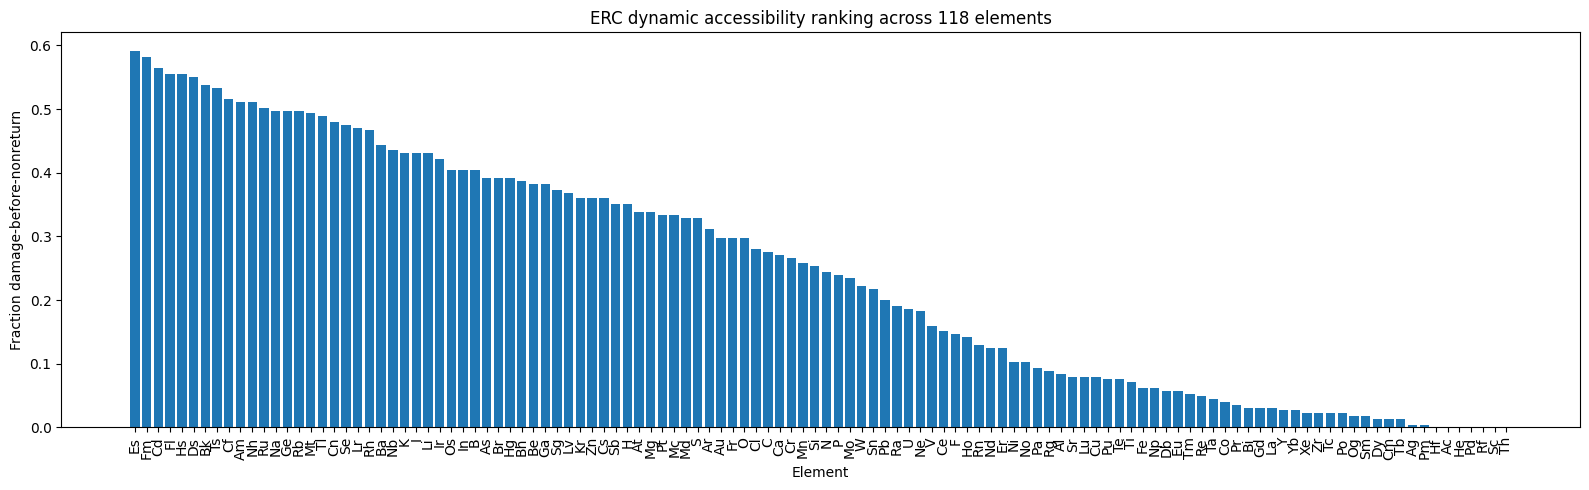

In [15]:
plt.figure(figsize=(16,5))

plt.bar(
    master_dynamic_erc_table_all["element"],
    master_dynamic_erc_table_all["frac_damage_before_nonreturn"]
)

plt.xticks(rotation=90)
plt.ylabel("Fraction damage-before-nonreturn")
plt.xlabel("Element")
plt.title("ERC dynamic accessibility ranking across 118 elements")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "figure_erc_ranking_118_elements.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

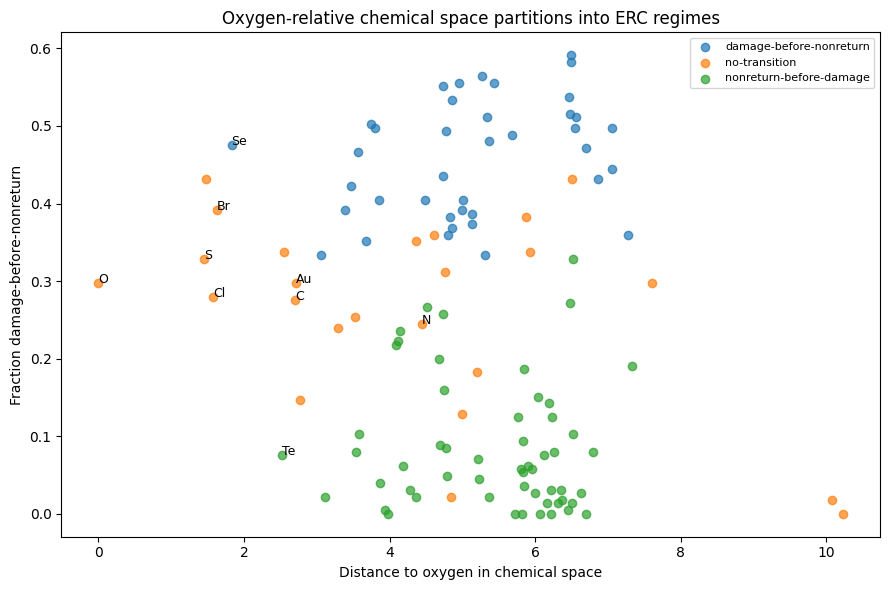

In [16]:
plt.figure(figsize=(9,6))

regime_order = [
    "damage-before-nonreturn",
    "no-transition",
    "nonreturn-before-damage"
]

for regime in regime_order:
    sub = merged_df[merged_df["dominant_regime"] == regime]
    if len(sub) > 0:
        plt.scatter(
            sub[distance_col],
            sub["frac_damage_before_nonreturn"],
            alpha=0.7,
            label=regime
        )

label_elements = ["O", "S", "C", "N", "Se", "Te", "Au", "Cl", "Br"]

for _, row in merged_df.iterrows():
    if row["element"] in label_elements:
        plt.text(
            row[distance_col],
            row["frac_damage_before_nonreturn"],
            row["element"],
            fontsize=9
        )

plt.xlabel("Distance to oxygen in chemical space")
plt.ylabel("Fraction damage-before-nonreturn")
plt.title("Oxygen-relative chemical space partitions into ERC regimes")
plt.legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "FINAL_paper_figure_oxygen_geometry_erc_regimes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Control and correlation

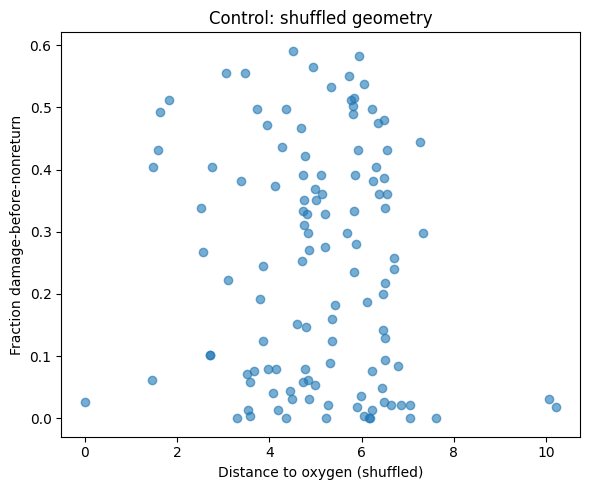

In [17]:
shuffled = merged_df.copy()
np.random.seed(42)
shuffled[distance_col] = np.random.permutation(shuffled[distance_col])

plt.figure(figsize=(6,5))

plt.scatter(
    shuffled[distance_col],
    shuffled["frac_damage_before_nonreturn"],
    alpha=0.6
)

plt.xlabel("Distance to oxygen (shuffled)")
plt.ylabel("Fraction damage-before-nonreturn")
plt.title("Control: shuffled geometry")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "figure_control_shuffled.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
corr = merged_df[distance_col].corr(
    merged_df["frac_damage_before_nonreturn"]
)

print("Correlation:", corr)

with open(OUTPUT_DIR / "correlation.txt", "w") as f:
    f.write(f"distance vs ERC correlation: {corr}\n")

Correlation: -0.16331146879458558


## 9. Minimal robustness sweep

In [ ]:
robust_configs = [
    (0.0, 0.1),
    (0.5, 0.1),
    (0.0, 0.25),
    (0.5, 0.25)
]

robust_results = []

for k, th in robust_configs:
    print("Running config:", k, th)

    rows = []
    for element in elements_to_run[:30]:
        df = run_element_pipeline(
            element,
            A_values=np.linspace(0.1, 5.0, 10),
            sigma_values=np.linspace(0.05, 1.5, 10),
            k_memory=k,
            damage_threshold=th
        )
        df["config"] = f"k={k},th={th}"
        rows.append(df)

    robust_results.append(pd.concat(rows))

df_robust = pd.concat(robust_results, ignore_index=True)

robustness_sweep_summary = (
    df_robust.groupby(["config", "regime"])
    .size()
    .reset_index(name="count")
)

robustness_sweep_summary.to_csv(
    OUTPUT_DIR / "robustness_sweep_summary.csv",
    index=False
)

display(robustness_sweep_summary)

Running config: 0.0 0.1
Running config: 0.5 0.1
Running config: 0.0 0.25
Running config: 0.5 0.25


## 10. Final output check

In [ ]:
print("Output files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p.name)

print("\nFigure files:")
for p in sorted(FIGURE_DIR.glob("*")):
    print("-", p.name)